## Hands-on

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Cleaned Dataset
df = pd.read_csv("/content/drive/MyDrive/Elogroup/CNH data literacy/Data League/Aula M4/Hands-on/coffee_sales_dataset.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         381 non-null    object 
 1   total_daily_sales_in_dollar  381 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.1+ KB


In [5]:
# date column to timestamp
df.date = pd.to_datetime(df.date)

In [6]:
# Printing the lowest date on dataset
df.date.min()

Timestamp('2024-03-01 00:00:00')

In [7]:
# Printing the highest date on dataset
df.date.max()

Timestamp('2025-03-23 00:00:00')

In [8]:
# Table Visualization
df.head()

,date,total_daily_sales_in_dollar
0,2024-03-01,396.3
1,2024-03-02,228.1
2,2024-03-03,349.1
3,2024-03-04,135.2
4,2024-03-05,338.5


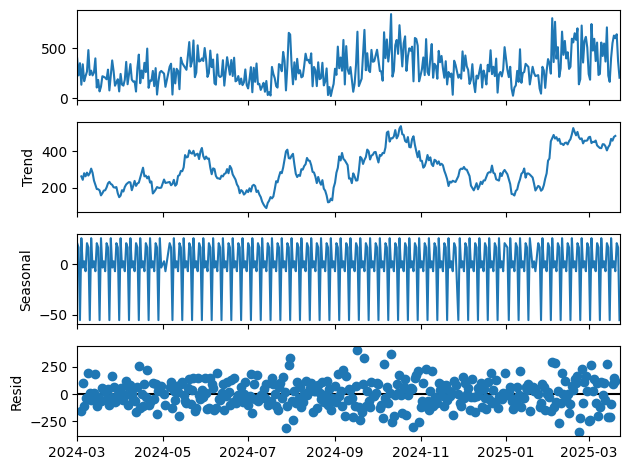

In [9]:
# Series Seasonal Decompose Plot Visualization
from statsmodels.tsa.seasonal import seasonal_decompose

df.index = df.date
df = df.drop(columns="date")

decomposition = seasonal_decompose(
    df,
    model="additive",
    period=7
)

fig = decomposition.plot()
plt.show()

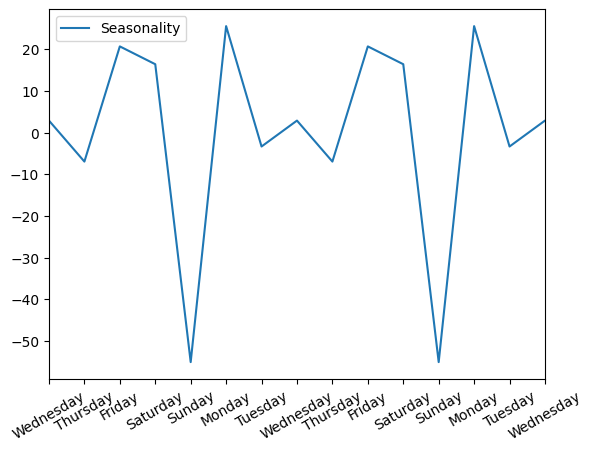

In [10]:
import matplotlib.dates as mdates

plt.plot(decomposition.seasonal, label="Seasonality")

# show only two weeks
start = df.index.min() + pd.Timedelta(days=5)
end = start + pd.Timedelta(days=14)

plt.xlim(start, end)

# show name of the day of the week on x axis
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%A"))
plt.xticks(rotation=30)

plt.legend()
plt.show()

### Forecasting sales for March 2025

In [11]:
# Splitting train, val, test
train_df = df[
    (df.index >= "2024-03-01") &
    (df.index <= "2024-11-30")
]

valid_df = df[
    (df.index >= "2024-12-01") &
    (df.index <= "2025-02-28")
]

test_df = df[
    (df.index >= "2025-03-01") &
    (df.index <= "2025-03-23")
]

In [12]:
# Fit SARIMAX model and find best parameters
import itertools

p = range(0, 3)
d = range(0, 2)
q = range(0, 3)

P = range(0, 2)
D = range(0, 2)
Q = range(0, 2)

orders = list(itertools.product(p, d, q))
seasonal_orders = list(itertools.product(P, D, Q))

m = 7  # weekly seasonality

best_mae = np.inf
best_order = None
best_seasonal_order = None
best_model = None

for order in orders:
    for seasonal_order in seasonal_orders:

        try:
            model = SARIMAX(
                train_df,
                order=order,
                seasonal_order=seasonal_order + (m,),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            result = model.fit(disp=False)

            # Skip models that did not converge
            if not result.mle_retvals["converged"]:
                continue

            # Forecast validation period
            valid_preds = result.forecast(steps=len(valid_df))

            mae = mean_absolute_error(valid_df, valid_preds)

            if mae < best_mae:
                best_mae = mae
                best_order = order
                best_seasonal_order = seasonal_order + (m,)
                best_model = result

        except:
            continue

print("Best order:", best_order)
print("Best seasonal order:", best_seasonal_order)
print("Validation MAE:", best_mae)

Best order: (2, 0, 2)
Best seasonal order: (0, 1, 1, 7)
Validation MAE: 130.69976388549895


In [13]:
# Do the validation set forecast
model = SARIMAX(
                train_df,
                order=(2,0,2),
                seasonal_order=(0,1,1,7),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
result = model.fit(disp=False)

valid_preds = result.forecast(steps=len(valid_df))

In [14]:
# Print MAE validation set metric
mae = mean_absolute_error(valid_df, valid_preds)
print(mae)

130.69976388549895


In [15]:
# Once you find the best parameter on validation set fit the final model with the best parameters
# Tip: Here you can join the train and val set to fit the model with the best parameters found.

train_valid_df = pd.concat([train_df, valid_df])

model = SARIMAX(
                train_valid_df,
                order=(2,0,2),
                seasonal_order=(0,1,1,7),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

result = model.fit(disp=False)

In [16]:
# Do the test set forecast
test_preds = result.forecast(steps=len(test_df))

In [17]:
# Print MAE test set metric
mae = mean_absolute_error(test_df, test_preds)
print(mae)

122.38436539923093


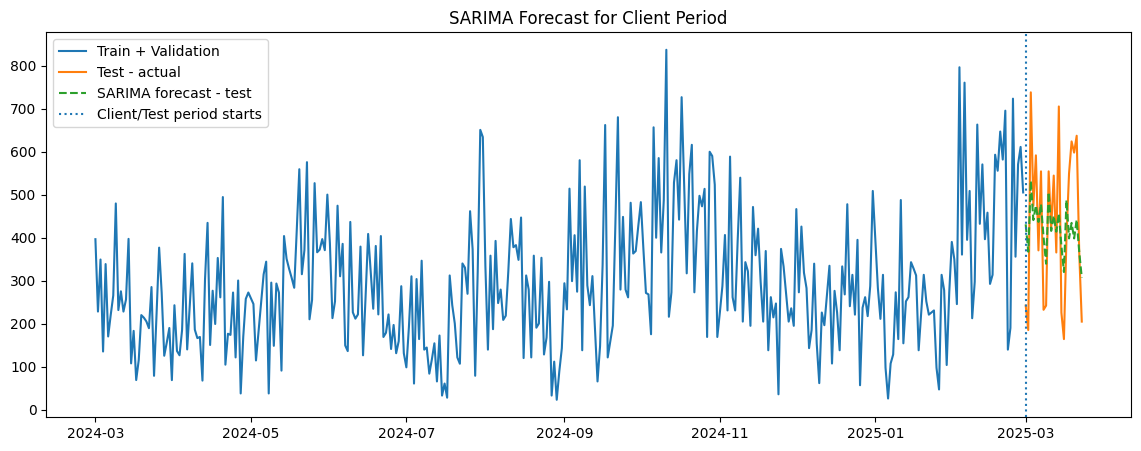

In [18]:
# Plot the train + validation serie, the test set and the sarima forest for the test set

plt.figure(figsize=(14, 5))

plt.plot(
    train_valid_df.index,
    train_valid_df["total_daily_sales_in_dollar"],
    label="Train + Validation"
)

plt.plot(
    test_df.index,
    test_df["total_daily_sales_in_dollar"],
    label="Test - actual"
)

plt.plot(
    test_df.index,
    test_preds,
    label="SARIMA forecast - test",
    linestyle="--"
)

plt.axvline(
    test_df.index.min(),
    linestyle=":",
    label="Client/Test period starts"
)

plt.title("SARIMA Forecast for Client Period")
plt.legend()
plt.show()


In [19]:
# All of march:

test_preds.sum()

np.float64(9676.079754312725)

### The End